In [16]:
import torch
import librosa
import numpy as np
import sys
import glob
import json
import os
import gc
from tqdm import tqdm
from collections import defaultdict
import argparse
import itertools
from pathlib import Path

sys.path.append(str((Path.home()/"github/Audio2AudioEchoes/dance-diffusion/audio_diffusion").absolute()))
sys.path.append(str((Path.home()/"github/Audio2AudioEchoes/src").absolute()))
sys.path.append(str((Path.home()/"github/Audio2AudioEchoes/").absolute()))
from echohiding import get_cepstrum, get_z_score
from utils import load_model_for_synthesis, do_style_transfer
from matplotlib import pyplot as plt

In [17]:
sample_size = 81920
sample_rate = 44100  
instruments = ["other"]
echoes = [75]
durs = [5]#, 10, 30, 60]
noise_levels = [0.1,0.2]

dataset = Path.home()/"datasets/raw/groove/drummer1/eval_session/"
pattern = "*.wav"

In [18]:
def eval_echo_models(param, model_path):
    """
    Z-score evaluation for single echo style transfer 
    """
    (idx, opt) = param
    (instrument, echo, noise_level) = list(itertools.product(instruments, echoes, noise_levels))[idx]
    dur = durs[0]
    torch.set_grad_enabled(False)

    files = list(dataset.glob(pattern))
    sr = opt.sr
    
    if not os.path.exists(model_path):
        print(model_path, "doesn't exist!  Aborting")
        return

    model = load_model_for_synthesis(model_path, sample_size, sample_rate, opt.device)
    torch.cuda.empty_cache()
    gc.collect()

    for fidx, f in [(0,files[-1])]:
        print(f"Doing idx {idx} file {f}, {fidx+1}/{len(files)}")
        x, _ = librosa.load(f, sr=sr)
        ## Pick out a 60 second chunk in the file
        if x.size < dur*sr:
            print(f"{f} too short, skipping")
            continue
        else:
            idx = np.random.randint(x.size-sr*dur)
            xi = x[idx:idx+sr*dur]
            n = sample_size*(xi.size//sample_size)
            xi = xi[0:n]
            xi = torch.from_numpy(xi[None, None, :]).to(opt.device)
            y = do_style_transfer(model, xi, steps=100, noise_level=noise_level,device=opt.device)
            y = y.detach().cpu().numpy()[0, 0, :]

            cep = get_cepstrum(y)
            csort = np.array(cep[0:opt.lag_end+1])
            plt.plot(range(opt.lag_start, opt.lag_end+1), csort[opt.lag_start:])
            plt.title(Path(model_path).name)
            plt.show()
            for test_echo in echoes:
                z = get_z_score(cep[0:opt.lag_end+1], test_echo, start_buff=opt.lag_start)
    return z, None

groove_75_full_dataset


Doing idx 0 file /home/tsroka/datasets/raw/groove/drummer1/eval_session/4_soul-groove4_80_beat_4-4.wav, 1/10


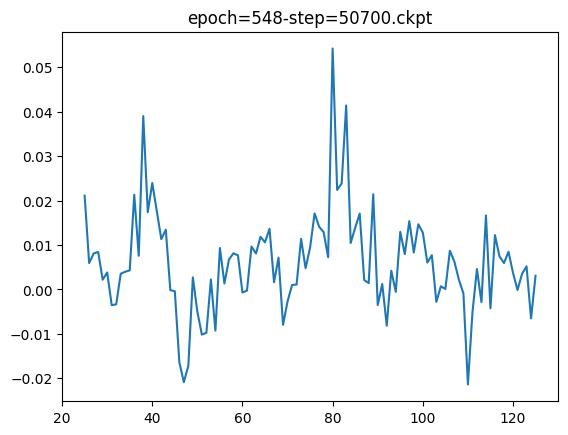

Doing idx 0 file /home/tsroka/datasets/raw/groove/drummer1/eval_session/4_soul-groove4_80_beat_4-4.wav, 1/10


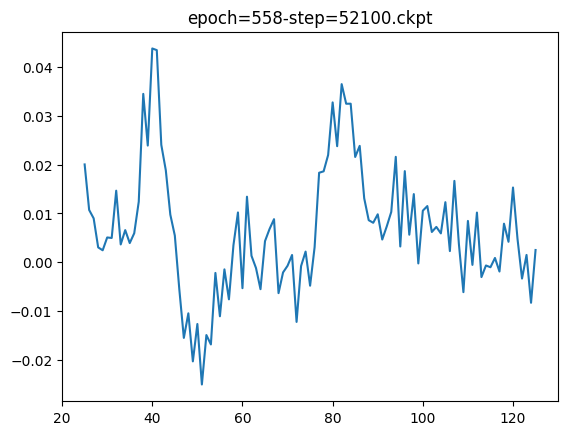

Doing idx 0 file /home/tsroka/datasets/raw/groove/drummer1/eval_session/4_soul-groove4_80_beat_4-4.wav, 1/10


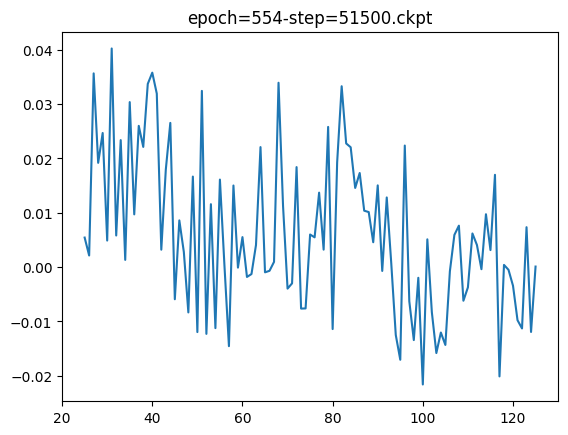

Doing idx 0 file /home/tsroka/datasets/raw/groove/drummer1/eval_session/4_soul-groove4_80_beat_4-4.wav, 1/10


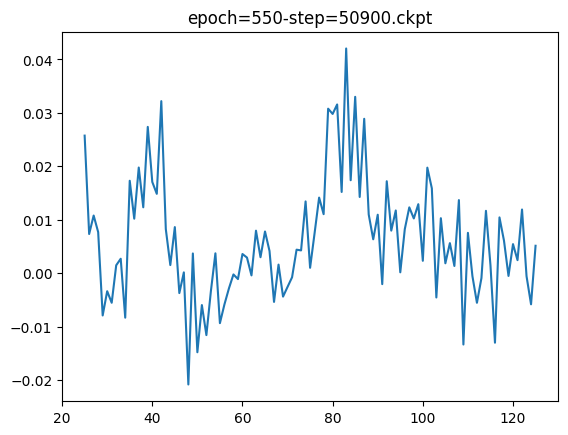

Doing idx 0 file /home/tsroka/datasets/raw/groove/drummer1/eval_session/4_soul-groove4_80_beat_4-4.wav, 1/10


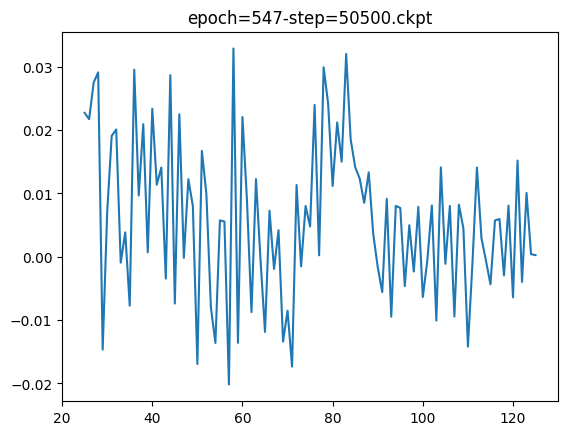

Doing idx 0 file /home/tsroka/datasets/raw/groove/drummer1/eval_session/4_soul-groove4_80_beat_4-4.wav, 1/10


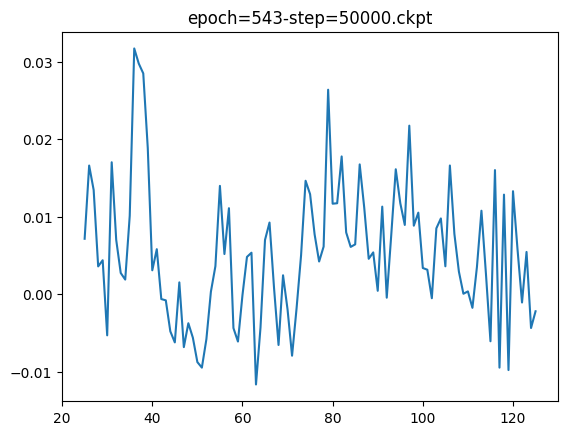

Doing idx 0 file /home/tsroka/datasets/raw/groove/drummer1/eval_session/4_soul-groove4_80_beat_4-4.wav, 1/10


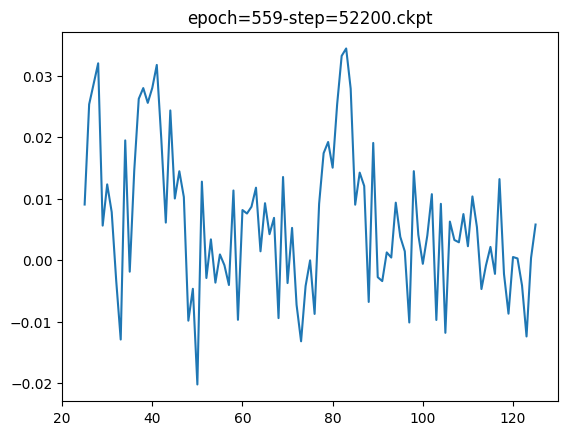

Doing idx 0 file /home/tsroka/datasets/raw/groove/drummer1/eval_session/4_soul-groove4_80_beat_4-4.wav, 1/10


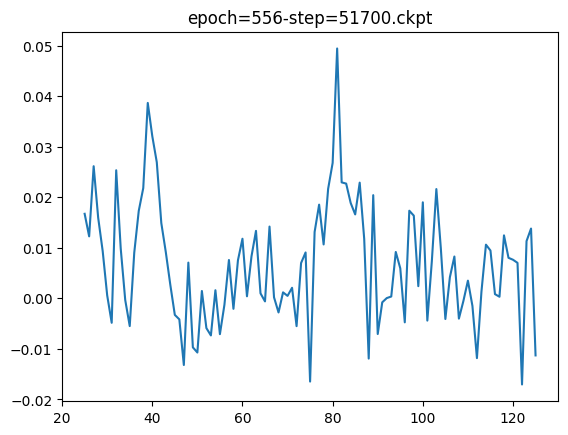

Doing idx 0 file /home/tsroka/datasets/raw/groove/drummer1/eval_session/4_soul-groove4_80_beat_4-4.wav, 1/10


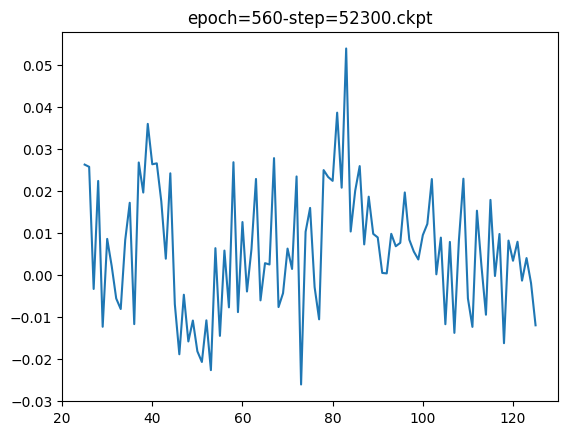

Doing idx 0 file /home/tsroka/datasets/raw/groove/drummer1/eval_session/4_soul-groove4_80_beat_4-4.wav, 1/10


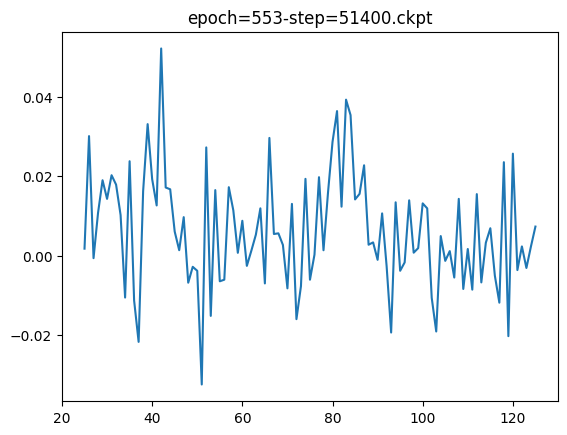

Doing idx 0 file /home/tsroka/datasets/raw/groove/drummer1/eval_session/4_soul-groove4_80_beat_4-4.wav, 1/10


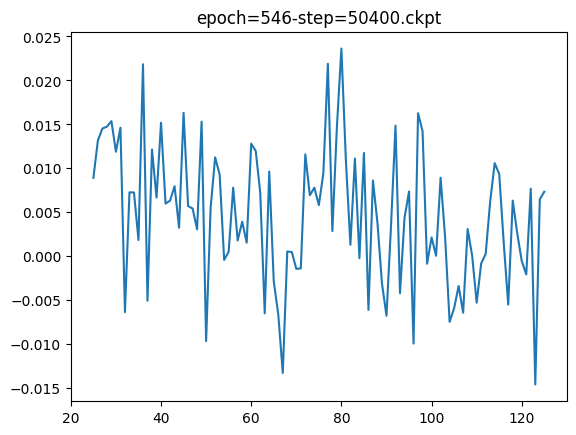

Doing idx 0 file /home/tsroka/datasets/raw/groove/drummer1/eval_session/4_soul-groove4_80_beat_4-4.wav, 1/10


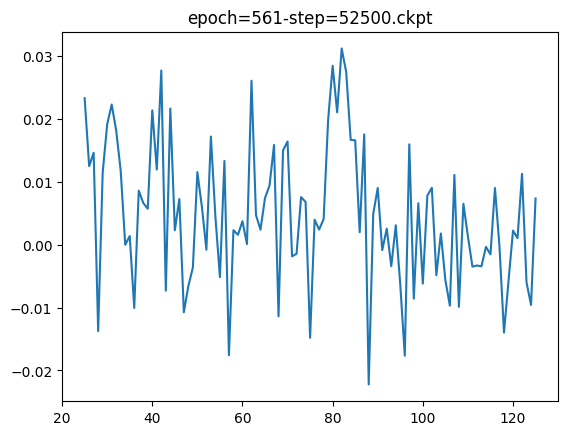

Doing idx 0 file /home/tsroka/datasets/raw/groove/drummer1/eval_session/4_soul-groove4_80_beat_4-4.wav, 1/10


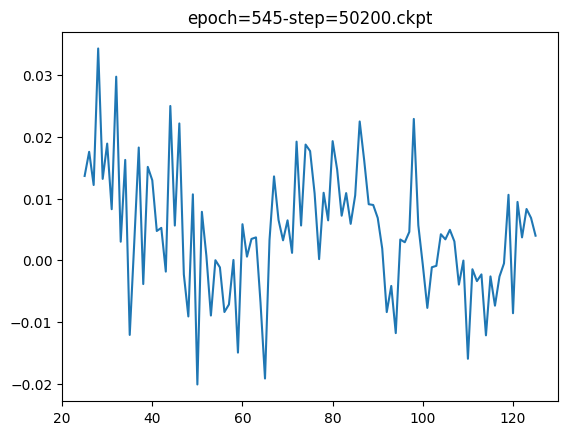

Doing idx 0 file /home/tsroka/datasets/raw/groove/drummer1/eval_session/4_soul-groove4_80_beat_4-4.wav, 1/10


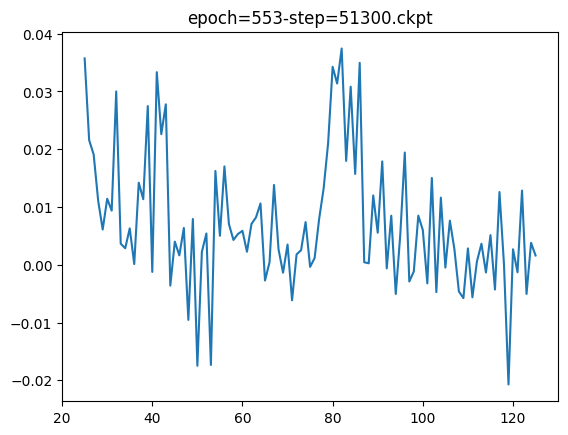

Doing idx 0 file /home/tsroka/datasets/raw/groove/drummer1/eval_session/4_soul-groove4_80_beat_4-4.wav, 1/10


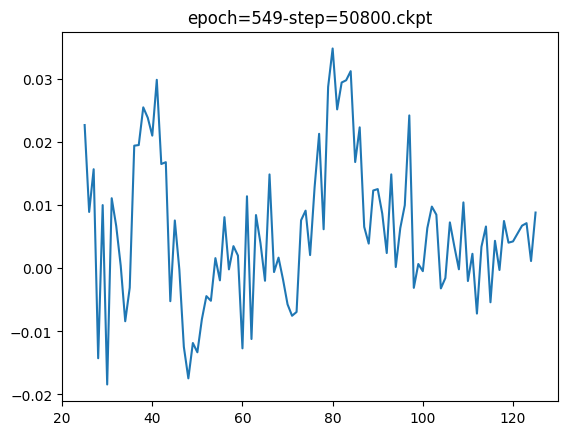

Doing idx 0 file /home/tsroka/datasets/raw/groove/drummer1/eval_session/4_soul-groove4_80_beat_4-4.wav, 1/10


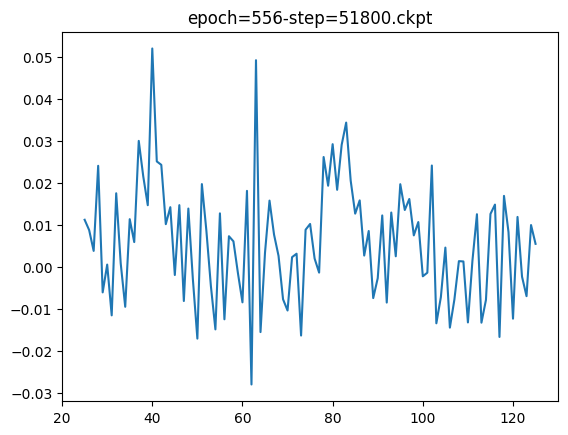

Doing idx 0 file /home/tsroka/datasets/raw/groove/drummer1/eval_session/4_soul-groove4_80_beat_4-4.wav, 1/10


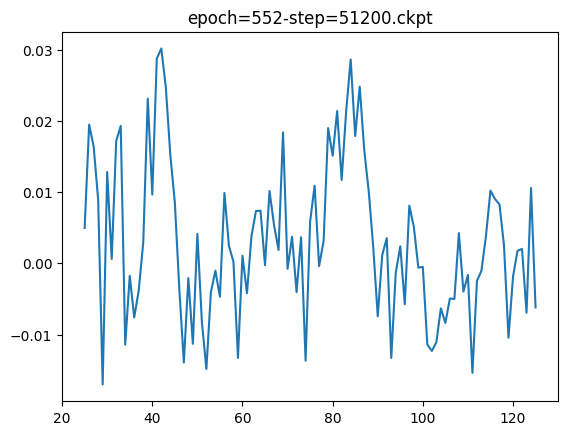

Doing idx 0 file /home/tsroka/datasets/raw/groove/drummer1/eval_session/4_soul-groove4_80_beat_4-4.wav, 1/10


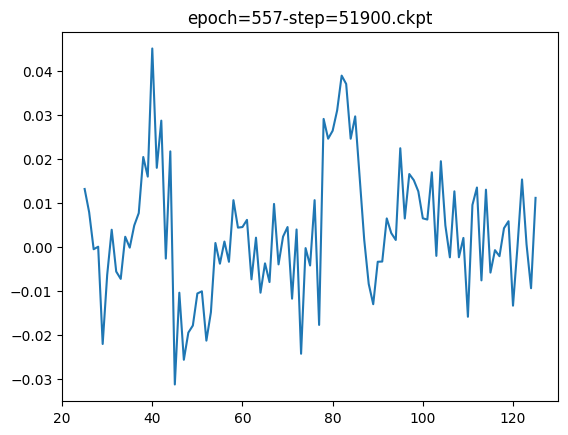

Doing idx 0 file /home/tsroka/datasets/raw/groove/drummer1/eval_session/4_soul-groove4_80_beat_4-4.wav, 1/10


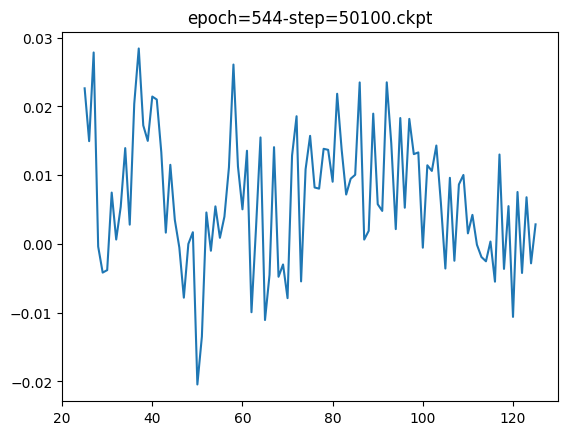

Doing idx 0 file /home/tsroka/datasets/raw/groove/drummer1/eval_session/4_soul-groove4_80_beat_4-4.wav, 1/10


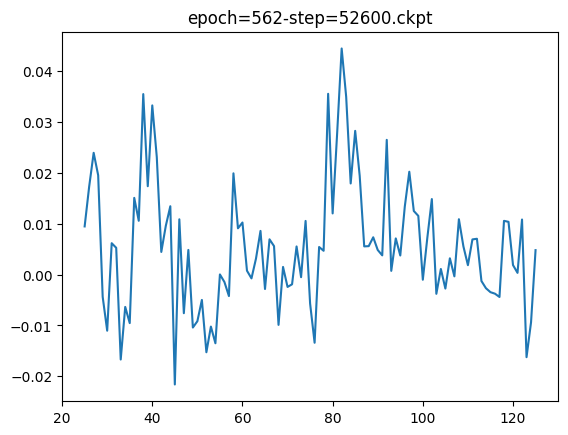

Doing idx 0 file /home/tsroka/datasets/raw/groove/drummer1/eval_session/4_soul-groove4_80_beat_4-4.wav, 1/10


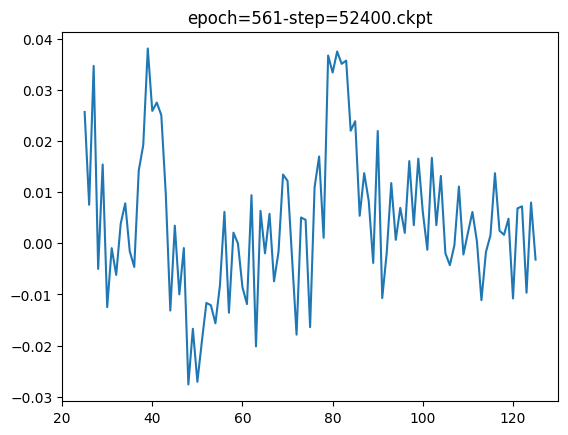

Doing idx 0 file /home/tsroka/datasets/raw/groove/drummer1/eval_session/4_soul-groove4_80_beat_4-4.wav, 1/10


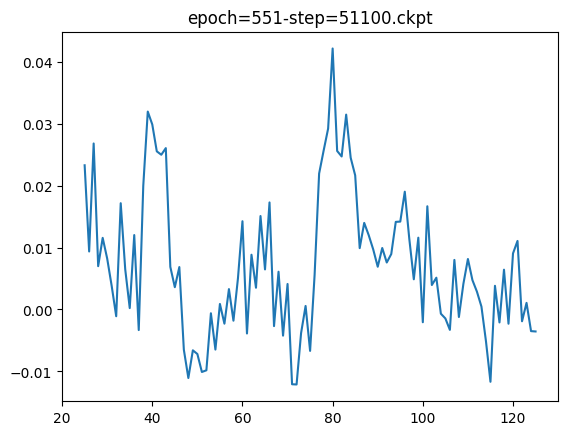

Doing idx 0 file /home/tsroka/datasets/raw/groove/drummer1/eval_session/4_soul-groove4_80_beat_4-4.wav, 1/10


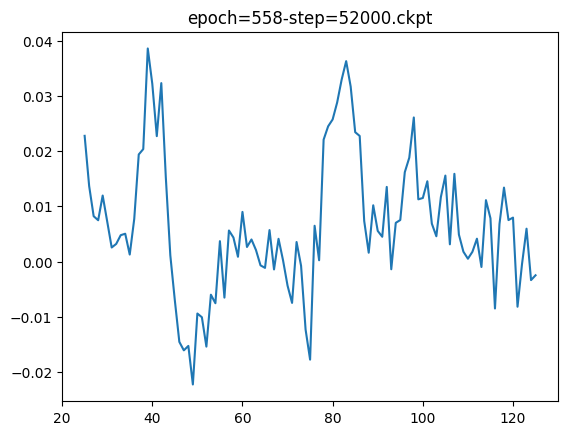

Doing idx 0 file /home/tsroka/datasets/raw/groove/drummer1/eval_session/4_soul-groove4_80_beat_4-4.wav, 1/10


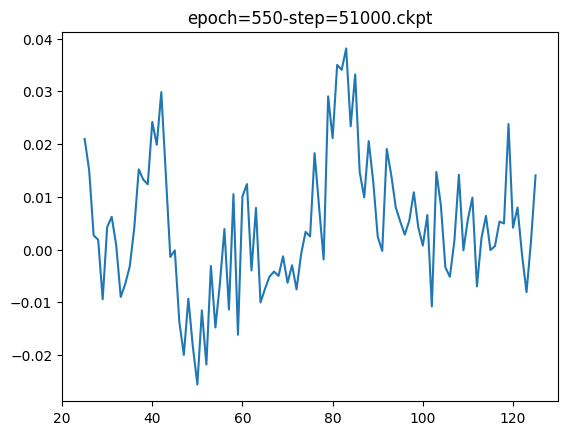

Doing idx 0 file /home/tsroka/datasets/raw/groove/drummer1/eval_session/4_soul-groove4_80_beat_4-4.wav, 1/10


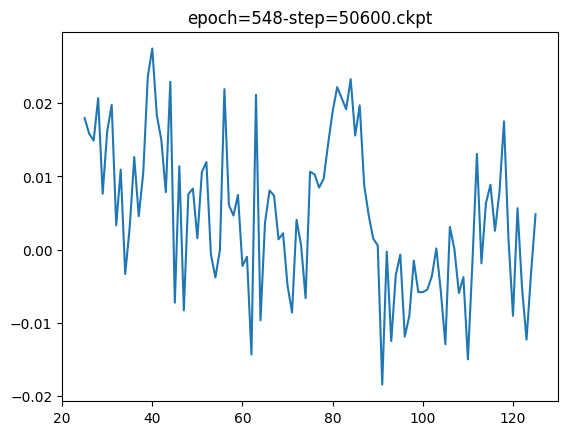

Doing idx 0 file /home/tsroka/datasets/raw/groove/drummer1/eval_session/4_soul-groove4_80_beat_4-4.wav, 1/10


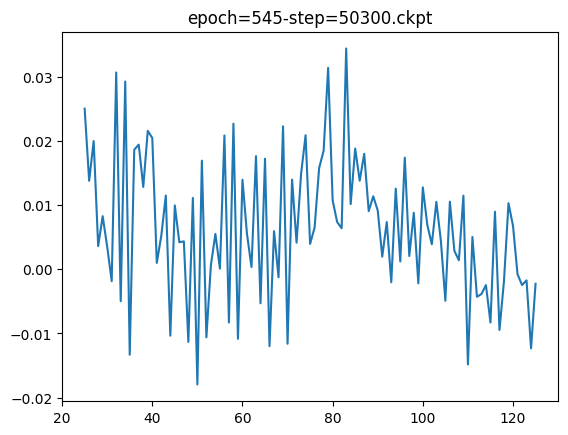

Doing idx 0 file /home/tsroka/datasets/raw/groove/drummer1/eval_session/4_soul-groove4_80_beat_4-4.wav, 1/10


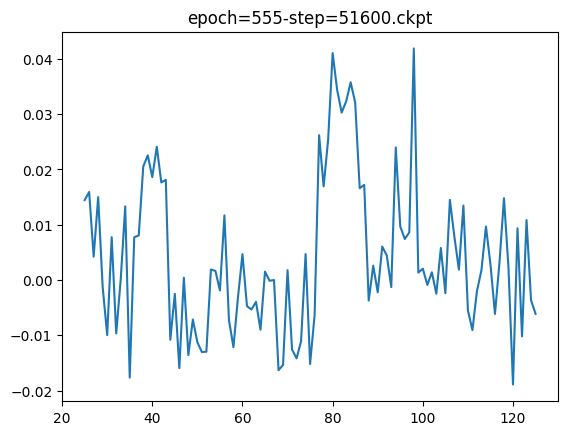

groove_75_10_files2
Doing idx 0 file /home/tsroka/datasets/raw/groove/drummer1/eval_session/4_soul-groove4_80_beat_4-4.wav, 1/10


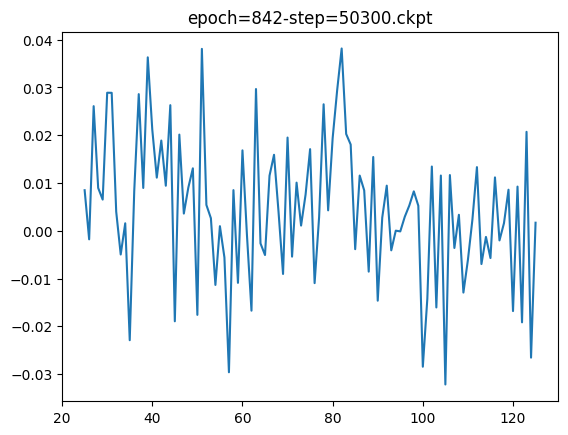

Doing idx 0 file /home/tsroka/datasets/raw/groove/drummer1/eval_session/4_soul-groove4_80_beat_4-4.wav, 1/10


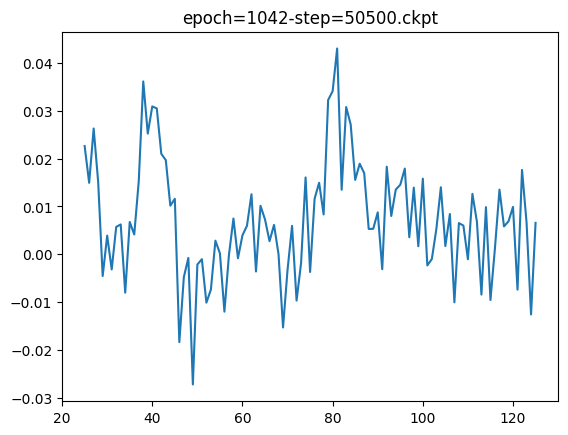

Doing idx 0 file /home/tsroka/datasets/raw/groove/drummer1/eval_session/4_soul-groove4_80_beat_4-4.wav, 1/10


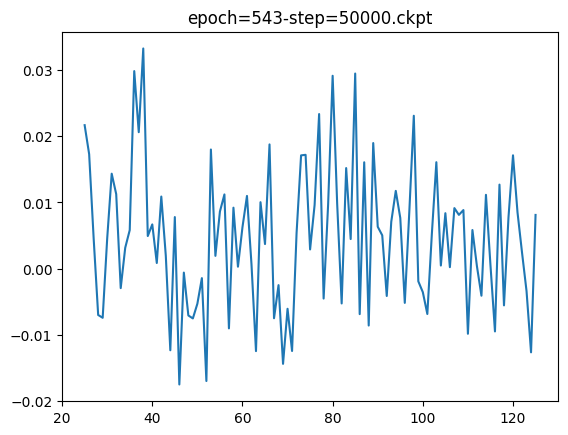

Doing idx 0 file /home/tsroka/datasets/raw/groove/drummer1/eval_session/4_soul-groove4_80_beat_4-4.wav, 1/10


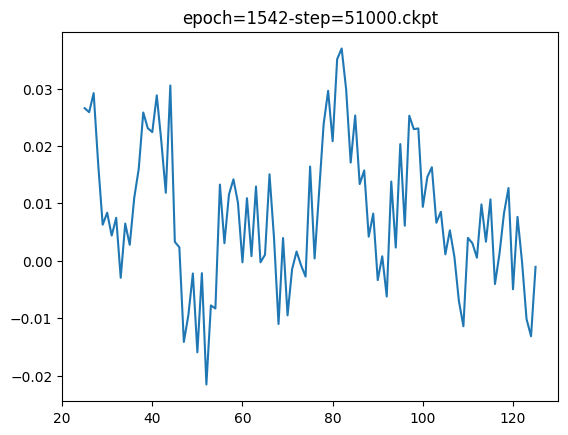

Doing idx 0 file /home/tsroka/datasets/raw/groove/drummer1/eval_session/4_soul-groove4_80_beat_4-4.wav, 1/10


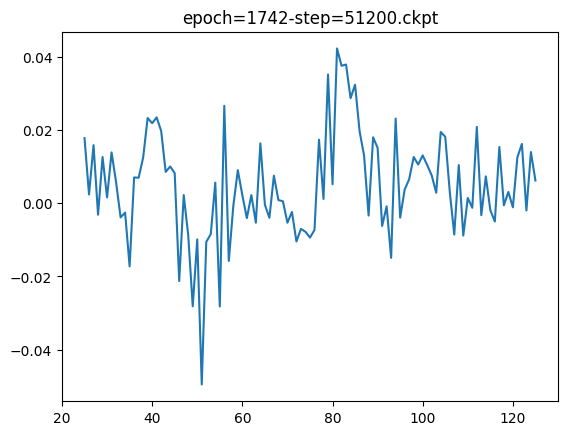

Doing idx 0 file /home/tsroka/datasets/raw/groove/drummer1/eval_session/4_soul-groove4_80_beat_4-4.wav, 1/10


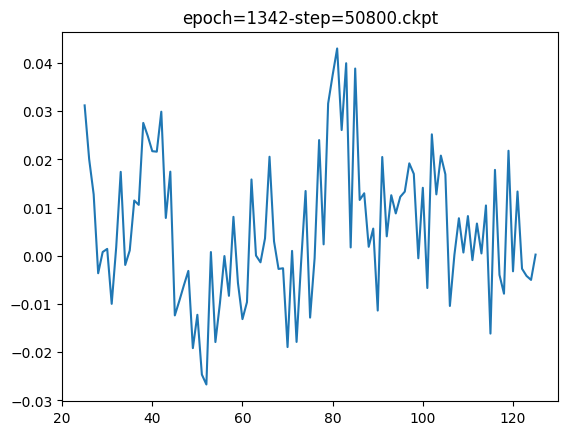

Doing idx 0 file /home/tsroka/datasets/raw/groove/drummer1/eval_session/4_soul-groove4_80_beat_4-4.wav, 1/10


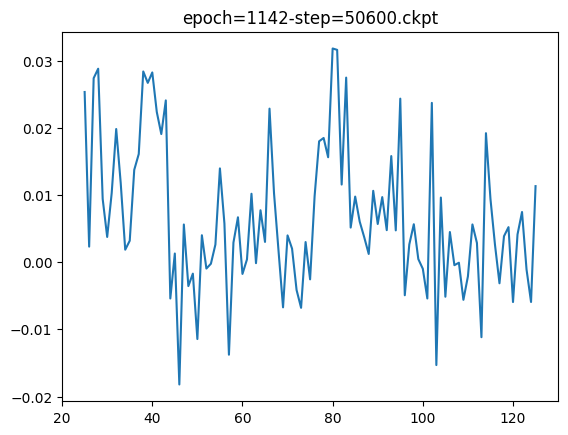

Doing idx 0 file /home/tsroka/datasets/raw/groove/drummer1/eval_session/4_soul-groove4_80_beat_4-4.wav, 1/10


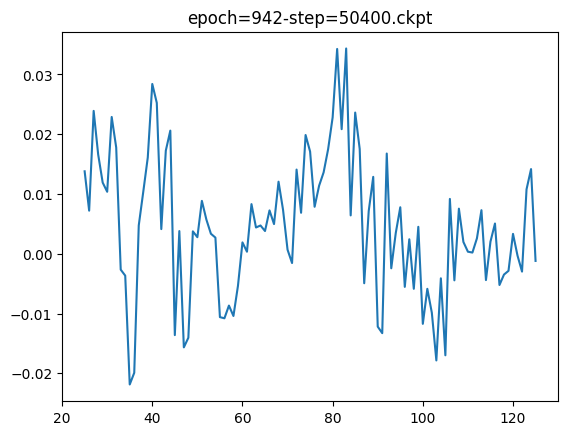

Doing idx 0 file /home/tsroka/datasets/raw/groove/drummer1/eval_session/4_soul-groove4_80_beat_4-4.wav, 1/10


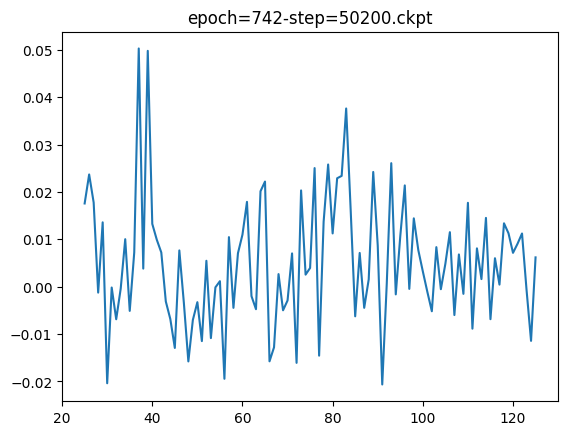

Doing idx 0 file /home/tsroka/datasets/raw/groove/drummer1/eval_session/4_soul-groove4_80_beat_4-4.wav, 1/10


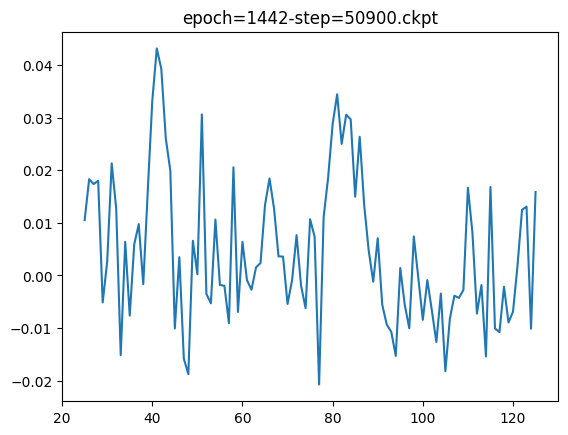

Doing idx 0 file /home/tsroka/datasets/raw/groove/drummer1/eval_session/4_soul-groove4_80_beat_4-4.wav, 1/10


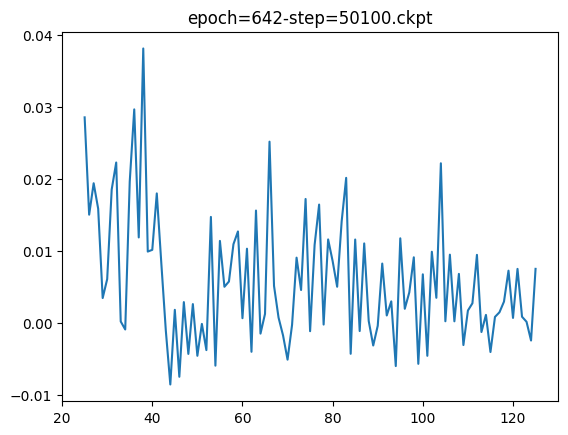

Doing idx 0 file /home/tsroka/datasets/raw/groove/drummer1/eval_session/4_soul-groove4_80_beat_4-4.wav, 1/10


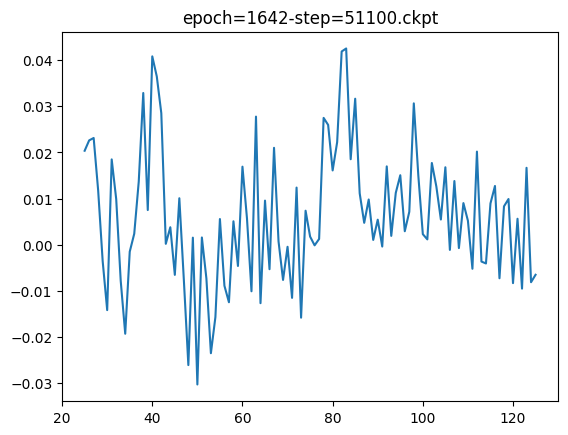

Doing idx 0 file /home/tsroka/datasets/raw/groove/drummer1/eval_session/4_soul-groove4_80_beat_4-4.wav, 1/10


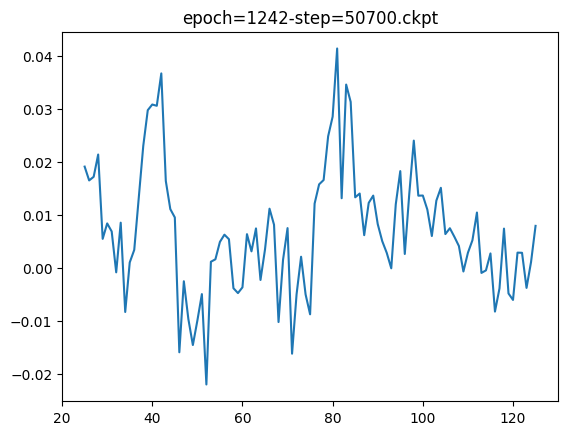

('groove_75_full_dataset', {50700: np.float64(0.2948042964868109), 52100: np.float64(-0.9004101717561946), 51500: np.float64(-0.017639466335698), 50900: np.float64(-0.47674789165597065), 50500: np.float64(-0.09330234781135867), 50000: np.float64(0.8735708459495193), 52200: np.float64(-0.5404191354024084), 51700: np.float64(-2.011417652782248), 52300: np.float64(0.6599165292865544), 51400: np.float64(-0.858649620187354), 50400: np.float64(0.15090780659573766), 52500: np.float64(-1.7741176231164142), 50200: np.float64(1.3040092557885221), 51300: np.float64(-0.6636780001892039), 50800: np.float64(-0.3415285646057368), 51800: np.float64(0.3012667658830126), 51200: np.float64(0.24352731102498185), 51900: np.float64(-0.5310049237249896), 50100: np.float64(0.9431968186718112), 52600: np.float64(-0.9177829564557476), 52400: np.float64(-1.4617461201712278), 51100: np.float64(-1.2375186175577528), 52000: np.float64(-2.02498769033944), 51000: np.float64(-0.15222667605724763), 50600: np.float64(0.

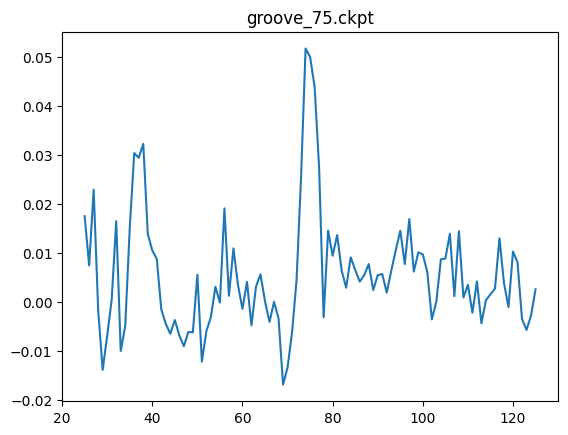

In [20]:
subpaths = ["groove_75_full_dataset","groove_75_10_files2"]
base = Path("../../finetune_outputs/dd/").resolve()
models = {s:list((base/s).glob("*.ckpt")) for s in subpaths}

opt = argparse.Namespace(n_chunks=1,sr=44100,lag_start=25,lag_end=125, device="cuda:0")
res = {}
for model in models:
    res[model] = {}
    print(model)
    for checkpoint in models[model]:
        z_score, rank = eval_echo_models((0, opt),checkpoint)
        res[model][int(checkpoint.stem.split("=")[2])] = z_score
for x in res.items():
    print(x)

# get baseline values
z_score_baseline, rank = eval_echo_models((0,opt),Path("../../ArtistProtectModels/SingleEchoes/DanceDiffusion/groove_75.ckpt").resolve())

In [21]:
for model in res:
    sorted_z_scores = []
    for k in sorted(res[model].keys()):
        sorted_z_scores.append(res[model][k])
    print(sorted_z_scores)

[np.float64(0.8735708459495193), np.float64(0.9431968186718112), np.float64(1.3040092557885221), np.float64(-0.23241145864556012), np.float64(0.15090780659573766), np.float64(-0.09330234781135867), np.float64(0.5852286536409388), np.float64(0.2948042964868109), np.float64(-0.3415285646057368), np.float64(-0.47674789165597065), np.float64(-0.15222667605724763), np.float64(-1.2375186175577528), np.float64(0.24352731102498185), np.float64(-0.6636780001892039), np.float64(-0.858649620187354), np.float64(-0.017639466335698), np.float64(-1.4291544111814063), np.float64(-2.011417652782248), np.float64(0.3012667658830126), np.float64(-0.5310049237249896), np.float64(-2.02498769033944), np.float64(-0.9004101717561946), np.float64(-0.5404191354024084), np.float64(0.6599165292865544), np.float64(-1.4617461201712278), np.float64(-1.7741176231164142), np.float64(-0.9177829564557476)]
[np.float64(-0.1598062945522962), np.float64(-0.8078750457029996), np.float64(-0.09149422312641539), np.float64(0.84

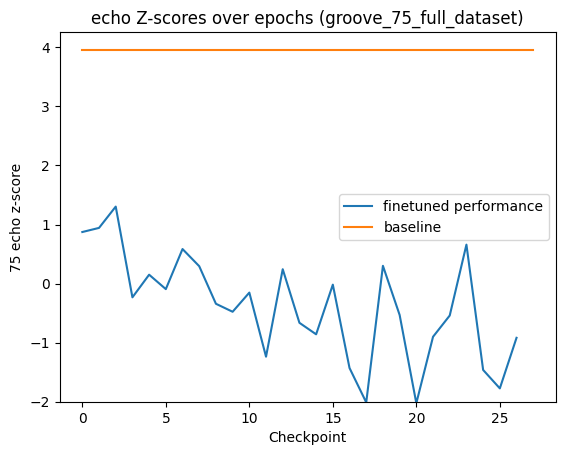

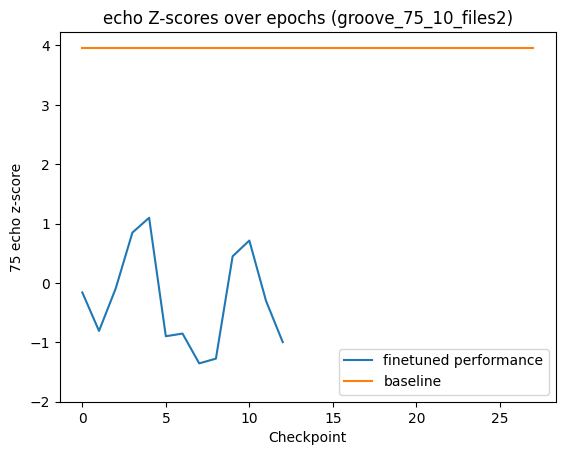

In [23]:
x_axis = max(len(res[m]) for m in res)
for model in res:
    sorted_z_scores = []
    for k in sorted(res[model].keys()):
        sorted_z_scores.append(res[model][k])

    plt.plot(sorted_z_scores, label="finetuned performance")
    plt.title(f"echo Z-scores over epochs ({model})")
    plt.xlabel("Checkpoint")
    plt.ylabel("75 echo z-score")
    plt.plot([0,x_axis],[z_score_baseline,z_score_baseline], label="baseline")
    plt.ylim(bottom=-2)
    plt.legend()
    plt.show()